# 🎵 Baseline Model — Music Genre Classification
**Dataset:** GTZAN (Mel Spectrogram images + CSV features)  
**Models:** 2D CNN (image-based) · Random Forest (hand-crafted features)  
**Evaluation:** F1-score (macro), Accuracy, Confusion Matrix

### Pipeline
```
Mel PNG images  →  2D CNN  →  Softmax  →  Genre prediction
features_30.csv →  Random Forest       →  Genre prediction
```

## 1. Install & Import

In [1]:
!pip install torch torchvision scikit-learn matplotlib seaborn pandas numpy tqdm -q

In [2]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
warnings.filterwarnings('ignore')

# ── PyTorch ──────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

# ── Scikit-learn ─────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

# ── Reproducibility ──────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Libraries loaded | Device: {DEVICE}')

✅ Libraries loaded | Device: cpu


## 2. Configuration

In [3]:
# ─── Paths (match data_preparation_mel.ipynb) ────────────────────────
MEL_PATH   = 'Data/mel_spectrograms'   # PNG images from data prep
CSV_PATH   = 'Data/features_30_sec.csv'  # hand-crafted features for RF

# ─── CNN params ──────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_EPOCHS  = 20
LR          = 1e-3

# ─── Split ratios ────────────────────────────────────────────────────
TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1
TEST_RATIO  = 0.1

GENRES = [
    'blues','classical','country','disco','hiphop',
    'jazz','metal','pop','reggae','rock'
]
NUM_CLASSES = len(GENRES)

print(f'✅ Config set | {NUM_CLASSES} genres | {NUM_EPOCHS} epochs')

✅ Config set | 10 genres | 20 epochs


---
# Part A — 2D CNN on Mel Spectrogram Images

## 3. DataLoader

In [4]:
# ── Transforms ───────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),          # mild augmentation
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

eval_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ── Load full dataset (labels = subfolder names) ──────────────────────
full_dataset = datasets.ImageFolder(MEL_PATH, transform=eval_transform)

# ── Split ─────────────────────────────────────────────────────────────
n_total = len(full_dataset)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
n_test  = n_total - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply augmentation only to training set
train_ds.dataset = datasets.ImageFolder(MEL_PATH, transform=train_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Dataset split → Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Classes: {full_dataset.classes}')

Dataset split → Train: 7984 | Val: 998 | Test: 999
Classes: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


## 4. Define the 2D CNN

In [5]:
class MelCNN(nn.Module):
    """
    Lightweight 2D CNN baseline for Mel Spectrogram images.
    Input : (B, 3, 224, 224)
    Output: (B, NUM_CLASSES)
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2),   # → 112×112
            nn.Dropout2d(0.25),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),   # → 56×56
            nn.Dropout2d(0.25),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),   # → 28×28
            nn.Dropout2d(0.25),

            # Block 4
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2, 2),   # → 14×14
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),   # global avg pool → (B, 256, 1, 1)
            nn.Flatten(),
            nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = MelCNN(num_classes=NUM_CLASSES).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ MelCNN ready | Params: {total_params:,}')
print(model)

✅ MelCNN ready | Params: 651,946
MelCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

## 5. Train the CNN

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}


def run_epoch(loader, train=True):
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total


best_val_acc = 0.0
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'best_cnn.pth')

    print(f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
          f'Loss {tr_loss:.4f}/{vl_loss:.4f} | '
          f'Acc {tr_acc:.4f}/{vl_acc:.4f}'
          + (' ✅ saved' if vl_acc == best_val_acc else ''))

print(f'\n🏆 Best val accuracy: {best_val_acc:.4f}')

Epoch   1/20 | Loss 1.9189/1.5719 | Acc 0.2818/0.4559 ✅ saved
Epoch   2/20 | Loss 1.6561/1.4466 | Acc 0.3784/0.4499
Epoch   3/20 | Loss 1.5409/1.3795 | Acc 0.4210/0.5030 ✅ saved
Epoch   4/20 | Loss 1.4492/1.2719 | Acc 0.4626/0.5531 ✅ saved
Epoch   5/20 | Loss 1.3791/1.1836 | Acc 0.4901/0.5912 ✅ saved
Epoch   6/20 | Loss 1.3362/1.1963 | Acc 0.5155/0.5872
Epoch   7/20 | Loss 1.2742/1.0695 | Acc 0.5416/0.6333 ✅ saved
Epoch   8/20 | Loss 1.2434/1.0293 | Acc 0.5492/0.6443 ✅ saved
Epoch   9/20 | Loss 1.1766/0.9983 | Acc 0.5828/0.6583 ✅ saved
Epoch  10/20 | Loss 1.1485/0.9017 | Acc 0.5942/0.7074 ✅ saved
Epoch  11/20 | Loss 1.0818/0.8599 | Acc 0.6201/0.7184 ✅ saved
Epoch  12/20 | Loss 1.0553/0.8468 | Acc 0.6301/0.7044
Epoch  13/20 | Loss 1.0076/0.8041 | Acc 0.6455/0.7375 ✅ saved
Epoch  14/20 | Loss 0.9798/0.7660 | Acc 0.6578/0.7475 ✅ saved
Epoch  15/20 | Loss 0.9558/0.7678 | Acc 0.6688/0.7335
Epoch  16/20 | Loss 0.9098/0.7213 | Acc 0.6830/0.7525 ✅ saved
Epoch  17/20 | Loss 0.8942/0.7133 | Acc 

## 6. Plot Training Curves

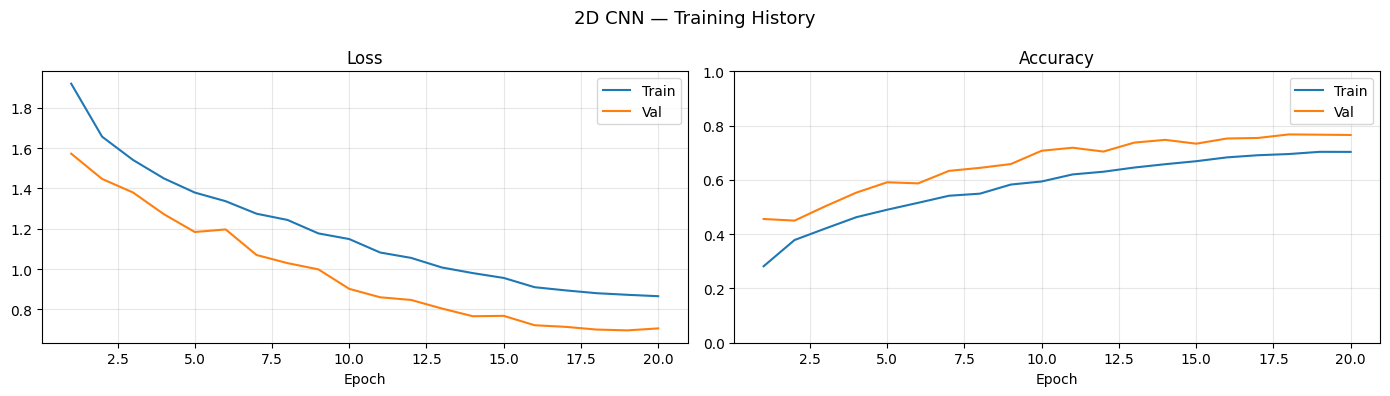

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_acc'], label='Train')
axes[1].plot(epochs, history['val_acc'],   label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('2D CNN — Training History', fontsize=13)
plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluate CNN on Test Set

In [8]:
# Load best checkpoint
model.load_state_dict(torch.load('best_cnn.pth', map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cnn_acc = accuracy_score(all_labels, all_preds)
cnn_f1  = f1_score(all_labels, all_preds, average='macro')

print(f'\n=== 2D CNN — Test Results ===')
print(f'Accuracy : {cnn_acc:.4f} ({cnn_acc*100:.2f}%)')
print(f'F1 (macro): {cnn_f1:.4f}')
print()
print(classification_report(all_labels, all_preds, target_names=GENRES))


=== 2D CNN — Test Results ===
Accuracy : 0.7427 (74.27%)
F1 (macro): 0.7270

              precision    recall  f1-score   support

       blues       0.74      0.74      0.74        95
   classical       0.87      0.94      0.90       124
     country       0.53      0.78      0.63        87
       disco       0.65      0.75      0.70        81
      hiphop       0.76      0.74      0.75        92
        jazz       0.85      0.74      0.79       108
       metal       0.81      0.91      0.86       104
         pop       0.70      0.81      0.75       101
      reggae       0.81      0.75      0.78        99
        rock       0.73      0.25      0.37       108

    accuracy                           0.74       999
   macro avg       0.74      0.74      0.73       999
weighted avg       0.75      0.74      0.73       999



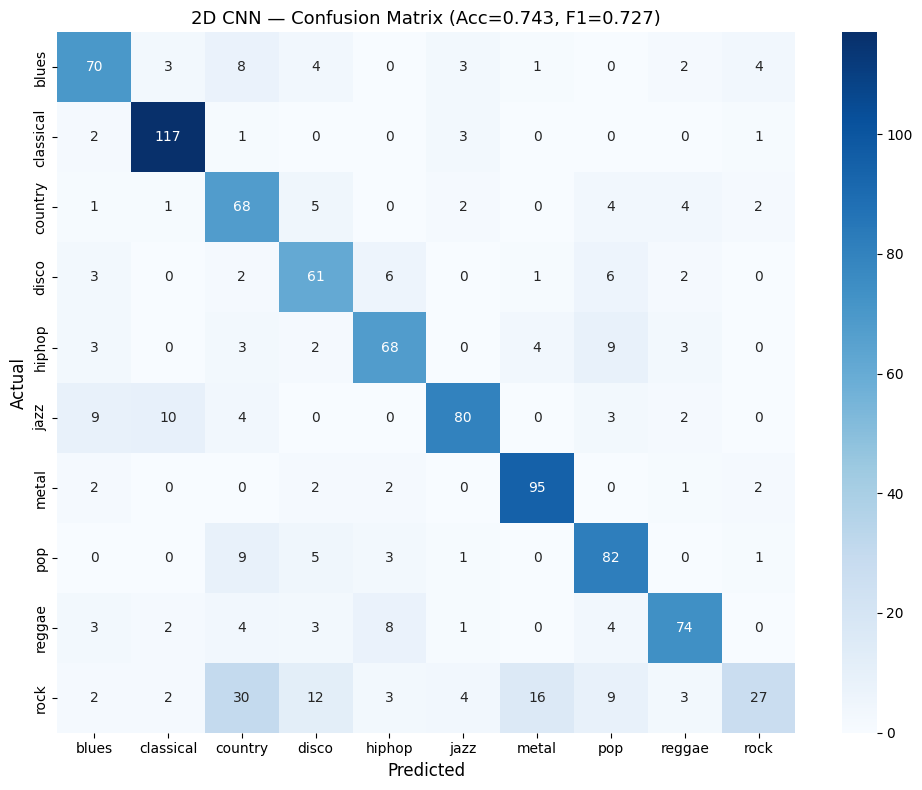

In [9]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRES, yticklabels=GENRES, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual',    fontsize=12)
ax.set_title(f'2D CNN — Confusion Matrix (Acc={cnn_acc:.3f}, F1={cnn_f1:.3f})', fontsize=13)
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part B — Random Forest on Hand-Crafted Features

## 8. Load & Preprocess CSV Features

In [10]:
df = pd.read_csv(CSV_PATH)
print(f'Shape: {df.shape}')
print(df.head(3))
print(f'\nLabel distribution:\n{df["label"].value_counts()}')

Shape: (1000, 60)
          filename  length  chroma_stft_mean  chroma_stft_var  rms_mean  \
0  blues.00000.wav  661794          0.350088         0.088757  0.130228   
1  blues.00001.wav  661794          0.340914         0.094980  0.095948   
2  blues.00002.wav  661794          0.363637         0.085275  0.175570   

    rms_var  spectral_centroid_mean  spectral_centroid_var  \
0  0.002827             1784.165850          129774.064525   
1  0.002373             1530.176679          375850.073649   
2  0.002746             1552.811865          156467.643368   

   spectral_bandwidth_mean  spectral_bandwidth_var  ...  mfcc16_var  \
0              2002.449060            85882.761315  ...   52.420910   
1              2039.036516           213843.755497  ...   55.356403   
2              1747.702312            76254.192257  ...   40.598766   

   mfcc17_mean  mfcc17_var  mfcc18_mean  mfcc18_var  mfcc19_mean  mfcc19_var  \
0    -1.690215   36.524071    -0.408979   41.597103    -2.303523   

In [11]:
# Drop non-feature columns
drop_cols = ['filename', 'length']  # adjust if column names differ
feature_cols = [c for c in df.columns if c not in drop_cols + ['label']]

X = df[feature_cols].values.astype(np.float32)
y_raw = df['label'].values

# Encode labels to integers
le = LabelEncoder()
y = le.fit_transform(y_raw)

# Train / Val / Test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=VAL_RATIO / (TRAIN_RATIO + VAL_RATIO),
    random_state=SEED, stratify=y_train
)

# Standardise features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f'Features  : {X.shape[1]}')
print(f'Train size: {len(X_train)}')
print(f'Val size  : {len(X_val)}')
print(f'Test size : {len(X_test)}')

Features  : 57
Train size: 800
Val size  : 100
Test size : 100


## 9. Train Random Forest

In [12]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=SEED,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

# Quick val check
val_preds = rf.predict(X_val)
rf_val_acc = accuracy_score(y_val, val_preds)
rf_val_f1  = f1_score(y_val, val_preds, average='macro')
print(f'✅ Random Forest trained')
print(f'   Val Accuracy: {rf_val_acc:.4f} | Val F1: {rf_val_f1:.4f}')

✅ Random Forest trained
   Val Accuracy: 0.7000 | Val F1: 0.6983


## 10. Evaluate Random Forest on Test Set

In [13]:
rf_preds = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
rf_f1  = f1_score(y_test, rf_preds, average='macro')

print(f'\n=== Random Forest — Test Results ===')
print(f'Accuracy : {rf_acc:.4f} ({rf_acc*100:.2f}%)')
print(f'F1 (macro): {rf_f1:.4f}')
print()
print(classification_report(y_test, rf_preds, target_names=le.classes_))


=== Random Forest — Test Results ===
Accuracy : 0.7400 (74.00%)
F1 (macro): 0.7374

              precision    recall  f1-score   support

       blues       0.75      0.90      0.82        10
   classical       0.91      1.00      0.95        10
     country       1.00      0.80      0.89        10
       disco       0.45      0.50      0.48        10
      hiphop       0.50      0.50      0.50        10
        jazz       0.90      0.90      0.90        10
       metal       0.80      0.80      0.80        10
         pop       0.75      0.90      0.82        10
      reggae       0.67      0.60      0.63        10
        rock       0.71      0.50      0.59        10

    accuracy                           0.74       100
   macro avg       0.74      0.74      0.74       100
weighted avg       0.74      0.74      0.74       100



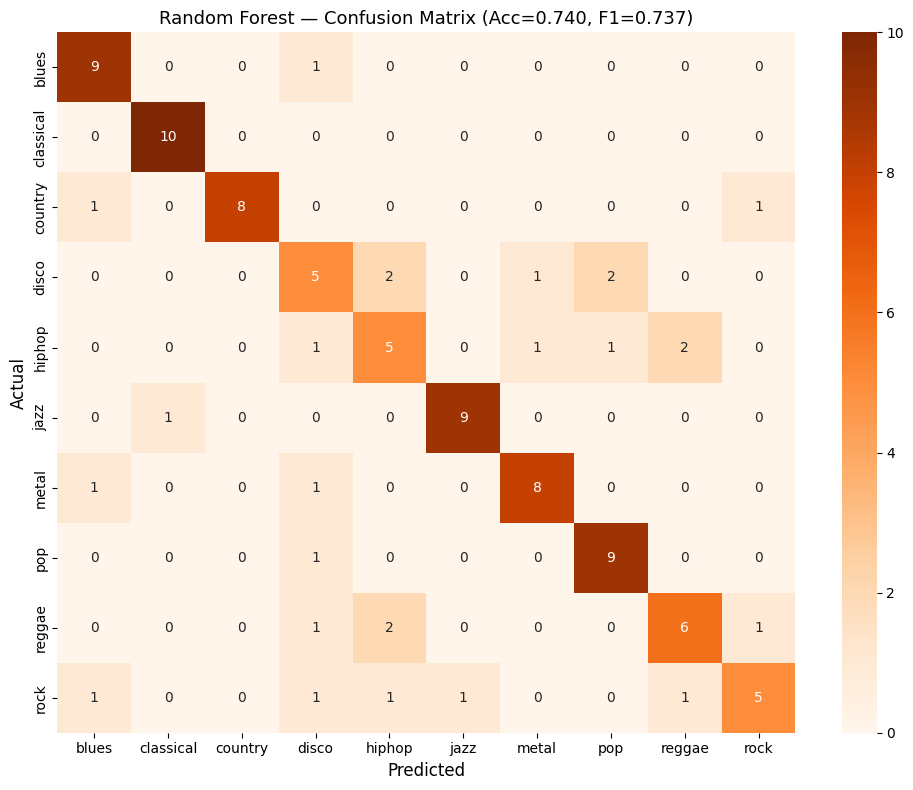

In [14]:
# Confusion Matrix — Random Forest
rf_cm = confusion_matrix(y_test, rf_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual',    fontsize=12)
ax.set_title(f'Random Forest — Confusion Matrix (Acc={rf_acc:.3f}, F1={rf_f1:.3f})', fontsize=13)
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Feature Importance (Random Forest)

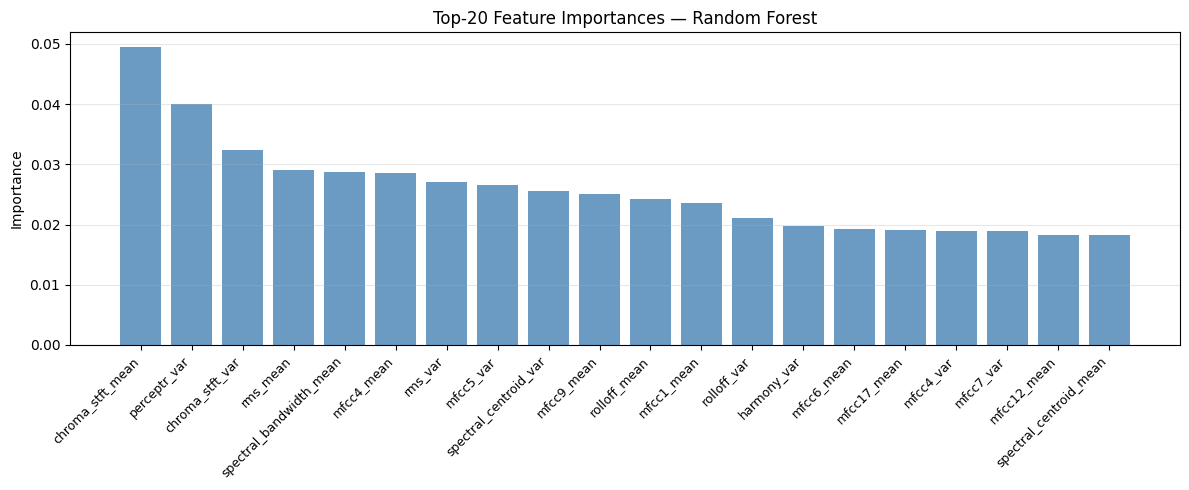

In [15]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # top 20

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(20), importances[indices], color='steelblue', alpha=0.8)
ax.set_xticks(range(20))
ax.set_xticklabels([feature_cols[i] for i in indices], rotation=45, ha='right', fontsize=9)
ax.set_title('Top-20 Feature Importances — Random Forest')
ax.set_ylabel('Importance')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part C — Compare Baselines

## 12. Summary Table

In [16]:
results = pd.DataFrame({
    'Model':    ['2D CNN (Mel Spectrogram)', 'Random Forest (CSV features)'],
    'Test Acc': [f'{cnn_acc:.4f}', f'{rf_acc:.4f}'],
    'F1 Macro': [f'{cnn_f1:.4f}',  f'{rf_f1:.4f}'],
    'Input':    ['Mel PNG images (224×224×3)', 'Hand-crafted features (CSV)'],
})
print(results.to_string(index=False))
results

                       Model Test Acc F1 Macro                       Input
    2D CNN (Mel Spectrogram)   0.7427   0.7270  Mel PNG images (224×224×3)
Random Forest (CSV features)   0.7400   0.7374 Hand-crafted features (CSV)


,Model,Test Acc,F1 Macro,Input
0,2D CNN (Mel Spectrogram),0.7427,0.7270,Mel PNG images (224×224×3)
1,Random Forest (CSV features),0.7400,0.7374,Hand-crafted features (CSV)


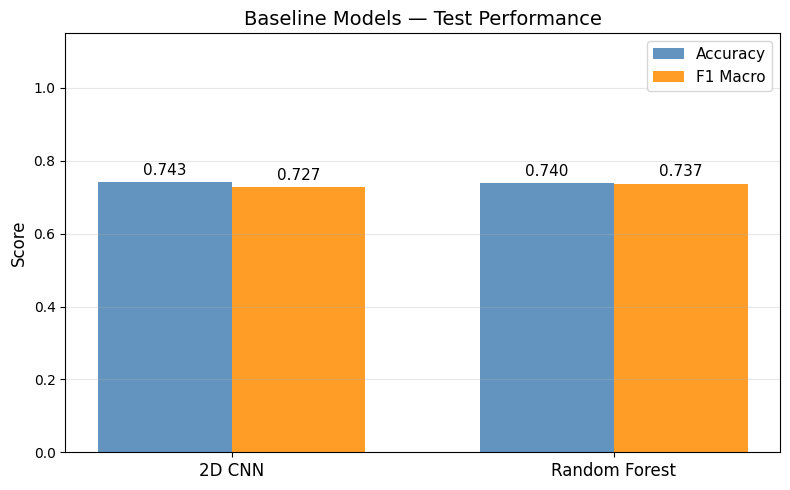


✅ All done! Models compared successfully.


In [17]:
# Bar chart comparison
labels_bar = ['2D CNN', 'Random Forest']
accs  = [cnn_acc, rf_acc]
f1s   = [cnn_f1,  rf_f1]
x = np.arange(len(labels_bar))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, accs, width, label='Accuracy', color='steelblue', alpha=0.85)
b2 = ax.bar(x + width/2, f1s,  width, label='F1 Macro',  color='darkorange', alpha=0.85)

ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=11)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=11)

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(labels_bar, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Baseline Models — Test Performance', fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ All done! Models compared successfully.')

---
## Notes for the team
| Item | Detail |
|---|---|
| **CNN input** | `Data/mel_spectrograms/` (output from `data_preparation_mel.ipynb`) |
| **RF input** | `Data/features_30_sec.csv` (GTZAN CSV features) |
| **Saved model** | `best_cnn.pth` (best val accuracy checkpoint) |
| **Evaluation** | Accuracy · F1 macro · Confusion Matrix (per spec in chat) |
| **Next steps** | Conformer / Fast Conformer (Part 4) · Real-time Sliding Window Pipeline (Part 5) |